## Deconvolution using geneformer (pseudobulk + single-cell reference) - cellHermes
This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. CellHermes embeddings are used throughout, though the workflow is fully adaptable to Geneformer, scGPT and Cell2Sentence. The tutorial covers the full pipeline: generating pseudobulk data, constructing signature matrices, extracting Geneformer embeddings from both the pseudobulk and single-cell reference signature datasets, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>

### Step 0: Load reference data (scRNA-seq)

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

### Step 1: Prep data for Geneformer

Load data uing scanpy and prep data for geneformer. `load_and_prep_data()` prepares the loaded anndata for geneformer by populating expected variables required by geneformer architecture.  Here we pass `mode = "geneformer"` since this is a geneformer based tutorial. However, if using cell2setence pass `mode = "c2s"`.

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata.var.index = adata.var["gene_name"]
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="c2s", organism="Homo Sapiens")

### Step 2: Create pseudobulk

In [6]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type", # cell type column
                                             n_pseudobulks = 500, # Number of pseudobulk samples to be created
                                             target_proportion_min = 0.1, # expected min cell type proportion
                                             target_proportion_max = 0.80, # expected max cell type proportion
                                             n_cells_per_pseudobulk = 300, # number of cells to be used for pseudobulking per sample
                                             random_state = 42 # random state for reproducibility
                                            )

### Step 3: Create signature matrix

In [7]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata,
                                  sample_col = "batch", # sample id column
                                  celltype_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

The signature matrix is constructed by averaging gene expression across the selected cell types, requiring no predefined gene markers. To build a signature matrix from a specific subset of samples, pass the desired sample IDs as a list. Here, all available samples are used, so `sample_id` is set to None.

### Step 4: Extract Geneformer Embeddings

In [8]:
from embeddings import *

geneformer is not installed. Skipping related functions.
cell2sentence is not installed. Skipping related functions.
cellhermes successfully imported.
scGPT is not installed. Skipping related functions.


In [10]:
sig_mat_ch_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "cellhermes", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True)

In [11]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "cellhermes",
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes", 
    delete_temp_files = True
)

[INFO|configuration_utils.py:673] 2026-06-16 16:04:58,038 >> loading configuration file /gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes/config.json
[INFO|configuration_utils.py:742] 2026-06-16 16:04:58,038 >> Model config LlamaConfig {
  "_name_or_path": "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes",
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
  

06/16/2026 16:04:58 - WARNING - llamafactory.model.loader - Processor was not found: 'LlamaConfig' object has no attribute 'vision_config'.
06/16/2026 16:04:58 - INFO - llamafactory.data.template - Replace eos token: <|eot_id|>


[INFO|configuration_utils.py:673] 2026-06-16 16:04:58,749 >> loading configuration file /gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes/config.json
[INFO|configuration_utils.py:742] 2026-06-16 16:04:58,750 >> Model config LlamaConfig {
  "_name_or_path": "/gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes",
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 128000,
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 131072,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_scaling": {
    "factor": 8.0,
    "high_freq_factor": 4.0,
  

06/16/2026 16:04:58 - INFO - llamafactory.model.patcher - Using KV cache for faster generation.


[INFO|modeling_utils.py:3729] 2026-06-16 16:04:58,751 >> loading weights file /gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes/model.safetensors.index.json
[INFO|modeling_utils.py:1622] 2026-06-16 16:04:58,751 >> Instantiating LlamaForCausalLM model under default dtype torch.float16.
[INFO|configuration_utils.py:1099] 2026-06-16 16:04:58,752 >> Generate config GenerationConfig {
  "bos_token_id": 128000,
  "eos_token_id": [
    128001,
    128008,
    128009
  ]
}



Loading checkpoint shards:   0%|          | 0/9 [00:00<?, ?it/s]

[INFO|modeling_utils.py:4574] 2026-06-16 16:05:04,141 >> All model checkpoint weights were used when initializing LlamaForCausalLM.

[INFO|modeling_utils.py:4582] 2026-06-16 16:05:04,141 >> All the weights of LlamaForCausalLM were initialized from the model checkpoint at /gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes.
If your task is similar to the task the model of the checkpoint was trained on, you can already use LlamaForCausalLM for predictions without further training.
[INFO|configuration_utils.py:1052] 2026-06-16 16:05:04,144 >> loading configuration file /gpfs/commons/groups/compbio/projects/rf_projects/rf_packages/CellHermes/model_ckpt/CellHermes/generation_config.json
[INFO|configuration_utils.py:1099] 2026-06-16 16:05:04,144 >> Generate config GenerationConfig {
  "bos_token_id": 128000,
  "do_sample": true,
  "eos_token_id": [
    128001,
    128008,
    128009
  ],
  "temperature": 0.6,
  "top_p": 0.9
}



06/16/2026 16:05:04 - INFO - llamafactory.model.model_utils.attention - Using torch SDPA for faster training and inference.
06/16/2026 16:05:04 - INFO - llamafactory.model.loader - all params: 8,030,261,248
A cell with genes ranked by expression: MALAT1 B2M TMSB4X EEF1A1 TPT1 FTL TMSB10 S100A9 FTH1 LYZ ACTB PTMA TXNIP FAU HLA-B GNLY UBA52 S100A4 NACA HLA-C S100A8 HLA-A NEAT1 RACK1 EIF1 S100A6 CD74 BTG1 NKG7 EEF1B2 HLA-DRA PTPRC CD52 DDX5 VIM HLA-E CTSS SH3BGRL3 ATP5F1E NFKBIA PFDN5 CYBA ACTG1 IGKC CALM1 OAZ1 SERF2 KLF2 PFN1 LTB SAT1 TOMM7 SRGN CCL5 EEF1D HMGB1 CFL1 TYROBP MYL6 PABPC1 MYL12A UBC UQCRB IL1B JUNB HNRNPA1 COX7C NPM1 ITM2B GAPDH ZFP36L2 S100A11 HNRNPA2B1 COX4I1 CST3 ARPC3 HLA-DRB1 BTF3 ARPC2 FOS SRSF5 HSP90AA1 PNRC1 YBX1 CD48 JUND CD37 IL7R ARHGDIB IL32 PPIA AIF1 CCL4 EMP3 EEF2 HCST LCP1 ATP5MG S100A10 HSP90AB1 FCN1 IFITM2 NOP53 NAP1L1 SRP14 TPM3 LGALS1 PNISR HLA-DPB1 CCL3 TMA7 FYB1 LAPTM5 SLC25A6 HLA-DPA1 HINT1 ARL4C G0S2 SARAF IER2 CORO1A ATP5MC2 PSAP TSC22D3 CXCR4 NCL VC

### Step 5: Run Non-Negative Least Squares (NNLS)

In [14]:
from deconvolution import *

In [16]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, #columns should be embedding dimensions
                            signature_df = sig_mat_ch_embed.T, #columns should be embedding dimensions
                            normalize = True)

Using 4096 common features.
Running deconvolution...


### Step 6: Evaluate estimated proportions

In [19]:
from evaluation import *

In [20]:
cell_prop.head()

,NK cells,T cells,Monocytes,B cells
T cells_PB1,0.216667,0.363333,0.236667,0.183333
B cells_PB2,0.053333,0.090000,0.090000,0.766667
T cells_PB3,0.123333,0.613333,0.130000,0.133333
Monocytes_PB4,0.156667,0.146667,0.520000,0.176667
T cells_PB5,0.276667,0.210000,0.233333,0.280000


In [21]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = cell_prop, # sample (rows) x cell type (columns)
                                 pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
NK cells,0.18025,0.203590
T cells,0.18025,0.200546
Monocytes,0.18025,0.143027
B cells,0.18025,0.166841


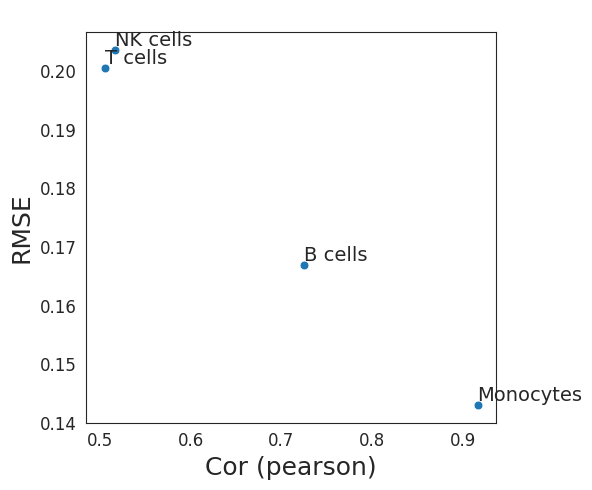

In [22]:
# Visualize RMSE - Correlation plot
# Both RMSE and Correlation coefficients are overall values (i.e not stratified by cell type)
sns.set_style("white")
plot_rmse_vs_corr_by_celltype(
    true_df = cell_prop,
    pred_df = cell_prop_pred
)

In [23]:
from visualization import *

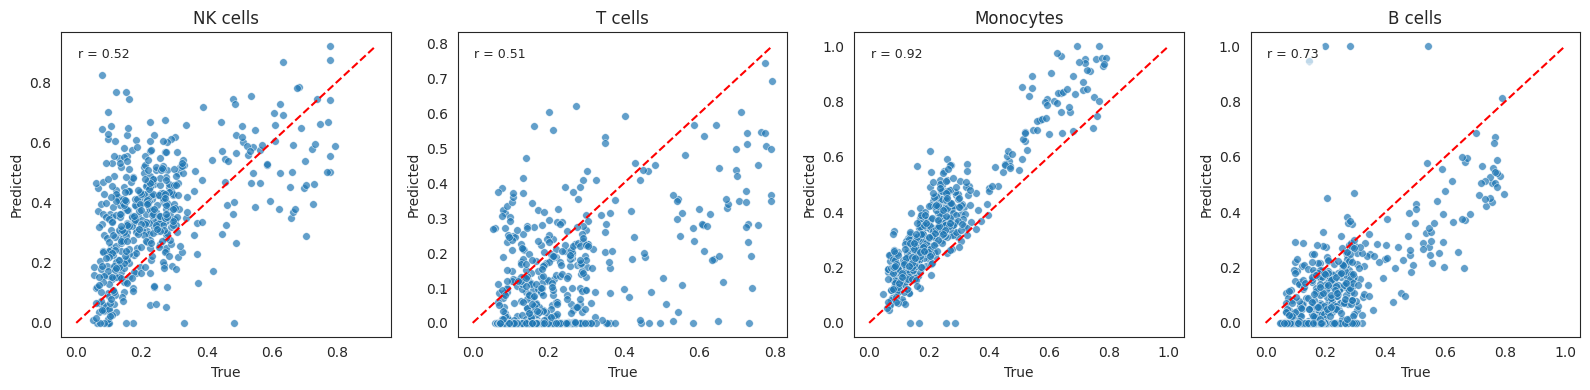

In [24]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
    
)

### Optional Step: Run Other Solvers

Using 4096 common features.
Running deconvolution...


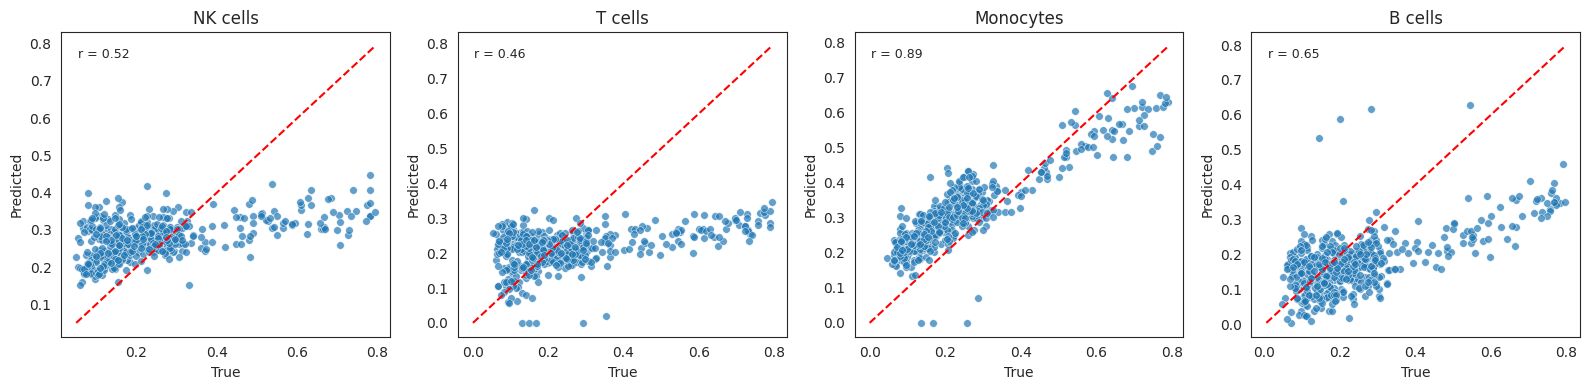

In [26]:
# Run ElasticNet
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                                 signature_df = sig_mat_ch_embed.T, 
                            solver= "elasticnet",
                                 normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)

In [29]:
# Run NuSVR
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_ch_embed.T, 
                            solver= "nusvr",
                            normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4))

Using 4096 common features.
Running deconvolution...


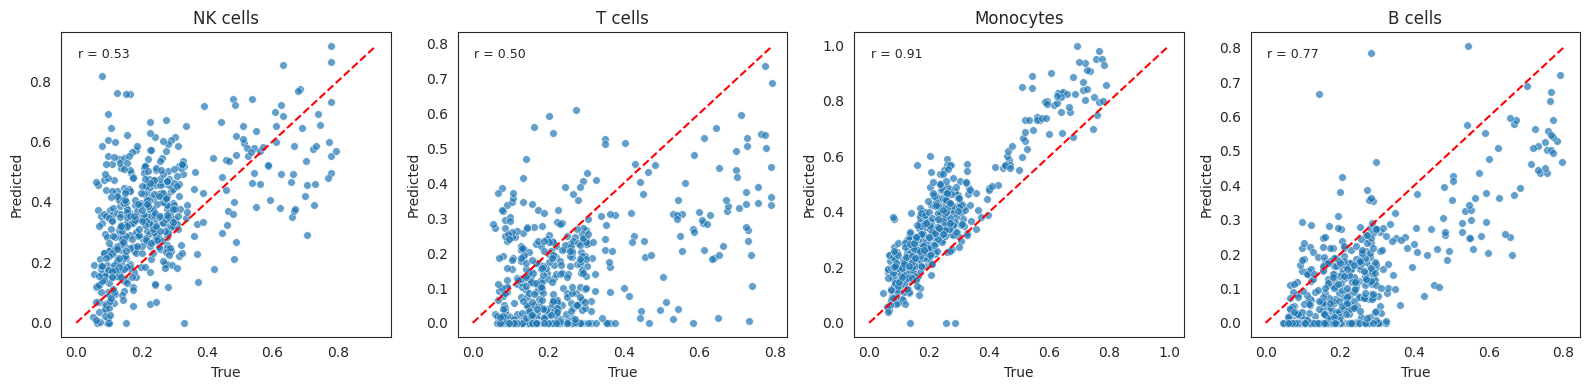

In [30]:
# Run ridge
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                                 signature_df = sig_mat_ch_embed.T, 
                            solver= "ridge",
                                 normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)